# **Set up**

In [1]:
%run ../../../setup_workspace.py # ../ means level up 
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d
import matplotlib.ticker as ticker
from scipy.fftpack import dct

# **Functions**

In [659]:
# ===== POROD (расширенный) =====
def porod(q, K, sigma, bg, use_sigma=True):
    if use_sigma:
        return K * q**(-4) * np.exp(-(q * sigma)**2) + bg
    else:
        return K * q**(-4) + bg

def fit_porod(q, I, q_range, fixed=None, use_sigma=True, K_factor=1.0):
    fixed = fixed or {}
    mask = (q >= q_range[0]) & (q <= q_range[1]) & (q > 0)
    x, y = q[mask], I[mask]
    
    if use_sigma:
        names = ['K', 'sigma', 'bg']
    else:
        names = ['K', 'bg']
    
    free = [p for p in names if p not in fixed]
    
    def model(q, *pars):
        vals = dict(fixed)
        for name, val in zip(free, pars):
            vals[name] = val
        if use_sigma:
            return vals['K'] * q**(-4) * np.exp(-(q * vals['sigma'])**2) + vals['bg']
        else:
            return vals['K'] * q**(-4) + vals['bg']
    
    bg0 = max(0, np.min(y))
    K0 = max(0.1, np.median((y - bg0) * x**4))
    
    if use_sigma:
        p0_dict = {'K': K0, 'sigma': 0.01, 'bg': bg0}
    else:
        p0_dict = {'K': K0, 'bg': bg0}
    
    p0 = [p0_dict[p] for p in free]
    lower = [0] * len(free)
    upper = [np.inf] * len(free)
    
    popt, _ = curve_fit(model, x, y, p0=p0, bounds=(lower, upper), maxfev=100000)
    
    params = dict(fixed)
    for name, val in zip(free, popt):
        params[name] = val
    
    # Умножаем K на коэффициент
    params['K'] = params['K'] * K_factor
    
    return params

# ===== BUILD CURVE с плавным переходом =====
def smooth_join(f, g, x, a, b):
    """
    Плавное соединение двух функций на интервале [a, b]
    f - левая функция (данные)
    g - правая функция (Porod)
    """
    x = np.asarray(x)
    y = np.zeros_like(x)
    
    # Весовая функция h(x) как в SasView
    h = 1.0 / (1.0 + ((x - b) / (x - a))**2)
    
    y = h * g(x) + (1 - h) * f(x)
    return y

def build_curve(q, I, guinier_range, porod_range, q_max=30, 
                fixed_guinier=None, fixed_porod=None,
                use_sigma=True, K_factor=1.0,
                smooth_width=0.3):
    q = np.asarray(q)
    I = np.asarray(I)
    
    # Guinier
    g = fit_guinier(q, I, guinier_range, fixed_guinier)
    
    # Левая граница Гинье = начало guinier_range
    q_start_guinier = guinier_range[0]
    q_low = np.linspace(0, q_start_guinier, 300)  # до левой границы фита
    I_low = guinier(q_low, g['A'], g['B'])
    
    # Данные от q_start_guinier до porod_range[0]
    mask = (q >= q_start_guinier) & (q <= porod_range[0])
    q_data = q[mask]
    I_data = I[mask]
    
    # Porod
    p = fit_porod(q, I, porod_range, fixed_porod, use_sigma, K_factor)
    
    q_start_porod = porod_range[0]
    q_high = np.linspace(q_start_porod, q_max, 1000)
    
    if use_sigma:
        I_high = porod(q_high, p['K'], p['sigma'], 0)
    else:
        I_high = p['K'] * q_high**(-4)
    
    # Собираем
    q_full = np.concatenate([q_low[:-1], q_data, q_high[1:]])
    I_full = np.concatenate([I_low[:-1], I_data, I_high[1:]])
    
    return q_full, I_full, g, p

def correlation(q, I, z_max=30, n_z=3000):
    dz = pi/max(q)
    z = np.linspace(dz, z_max, n_z)
    Q_star = np.trapezoid(I * q**2, q)
    cos_mat = np.cos(np.outer(z, q))
    Gamma = np.trapezoid(I * q**2 * cos_mat, q, axis=1) / Q_star
    return z, Gamma, Q_star

# ===== IDF =====
def idf(q, I, z_max=30, n_z=3000):
    dz = pi/max(q)
    z = np.linspace(dz, z_max, n_z)
    Q_star = np.trapezoid(I * q**2, q)
    cos_mat = np.cos(np.outer(z, q))
    IDF = np.trapezoid(I * q**4 * cos_mat, q, axis=1) / Q_star
    return z, IDF, Q_star

# **Data**

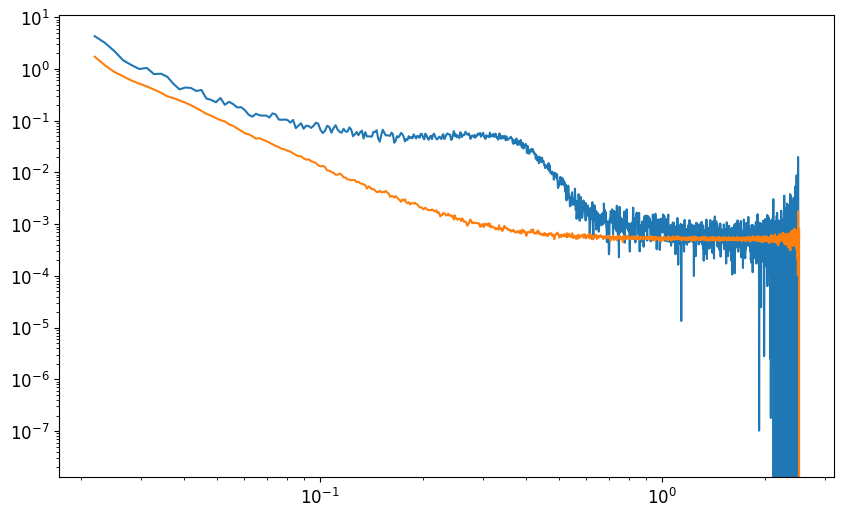

In [660]:

path = r"\\Synology\Data\2025\ESRF_SC5671\ef20\ef20_20250620-091305\ef20_eiger2_00293_00_ave.h5"

Exp_Heat = ID02_experiment(path)
q, I = Exp_Heat.get_1d_data(85
                           )
plt.loglog(q, I)

path = r'\\Synology\Data\2025\ESRF_SC5671\ef20\ef20_20250620-091305\ef20_eiger2_00034_00_ave.h5'
q, bkg1 = ID02_experiment(path).get_1d_data()

path = r'\\Synology\Data\2025\ESRF_SC5671\ef20\ef20_20250620-091305\ef20_eiger2_00038_00_ave.h5'
q, bkg2 =  ID02_experiment(path).get_1d_data()

path = r'\\Synology\Data\2025\ESRF_SC5671\ef20\ef20_20250620-091305\ef20_eiger2_00037_00_ave.h5'
q, bkg3 =  ID02_experiment(path).get_1d_data()

bkg =( bkg1 + bkg2 + bkg3) / 3
plt.loglog(q, bkg)
q
# plt.loglog(q, I - bkg)
I -= bkg

# **Analysis**

In [661]:
def average(Exp, index):
    q, res = Exp.get_1d_data()
    res *= 0
    
    for i in index:
        q, I = Exp.get_1d_data(i)
        res += I
    res /= len(index)
    return q, res

In [662]:
def smooth_porod_region(q, I, porod_range, window=5):
    """
    Сглаживает только область фита Porod
    """
    I_smooth = np.copy(I)
    mask = (q >= porod_range[0]) & (q <= porod_range[1])
    
    if np.sum(mask) > window:
        from scipy.ndimage import uniform_filter1d
        I_smooth[mask] = uniform_filter1d(I[mask], size=window, mode='nearest')
    
    return I_smooth


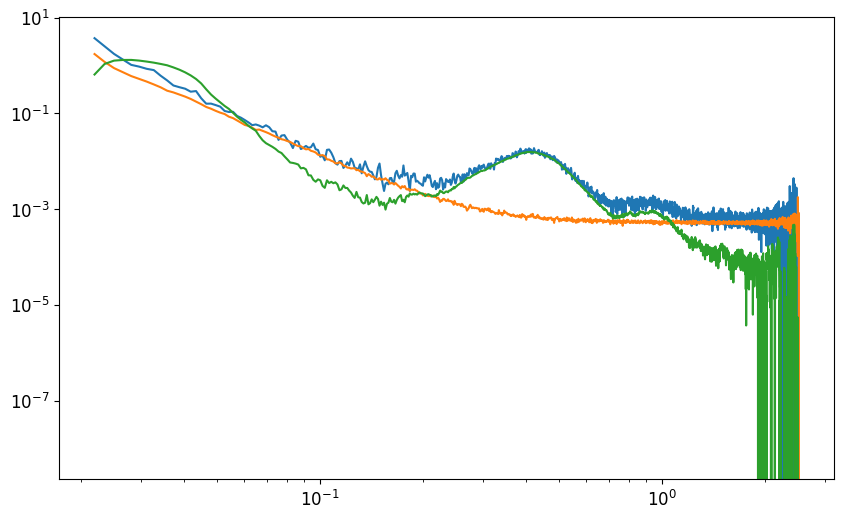

In [780]:
i = 10
q, I = average(Exp_Heat, [i*2, i*2+1, i*2+2])

plt.loglog(q, I)
plt.loglog(q, bkg)

I_smooth = smooth_porod_region(q, I, (.02, 20), window=30)
I_smooth-=bkg
plt.loglog(q, I_smooth)



In [768]:
def cos_ft(q, y, z):
    """
    Простое косинус-преобразование Фурье
    
    F(z) = ∫ y(q) * cos(q*z) dq
    
    Parameters:
    q, y : массивы (произвольная сетка)
    z : массив координат в реальном пространстве
    
    Returns:
    F : массив преобразования
    """
    F = np.zeros(len(z))
    for i, zi in enumerate(z):
        F[i] = np.trapezoid(y * np.cos(q * zi), q)
    return F

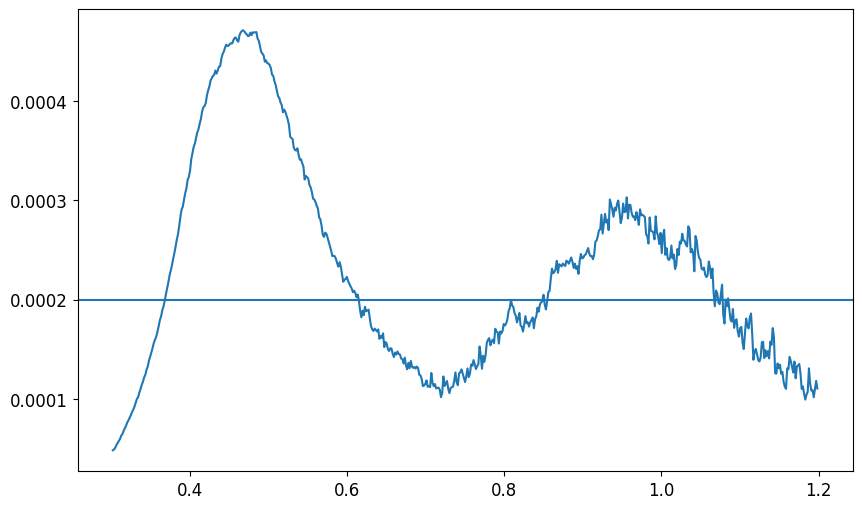

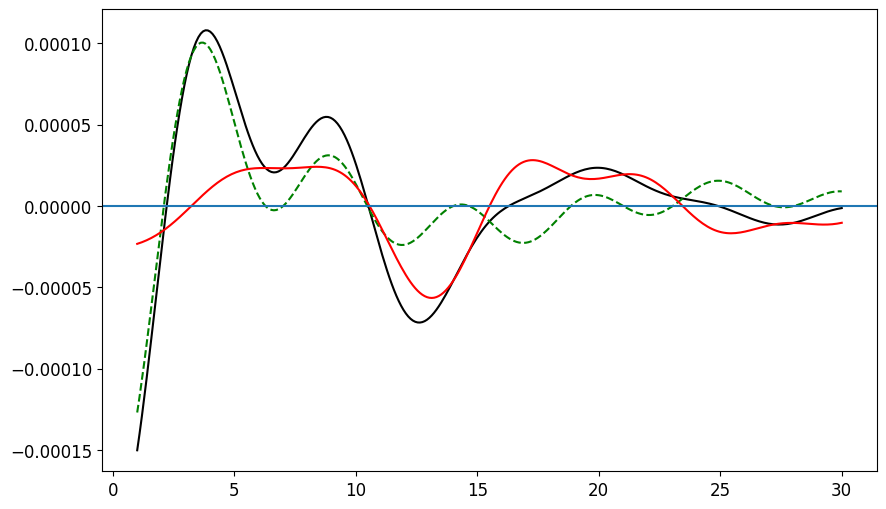

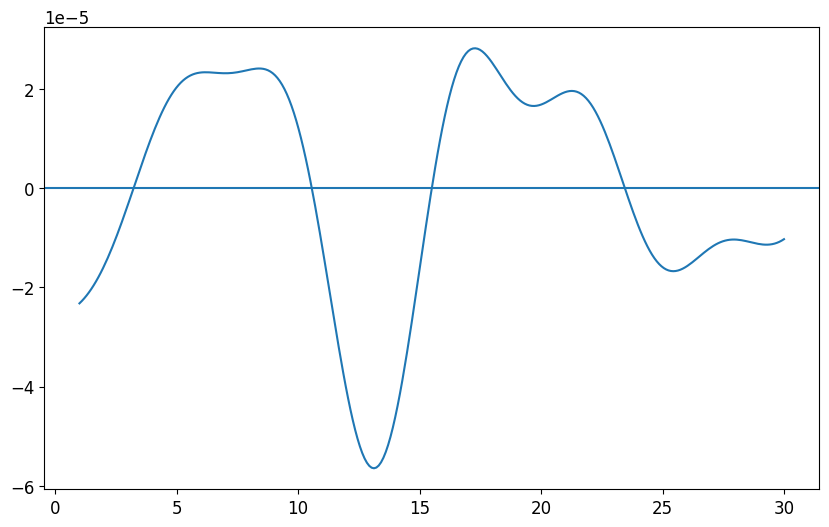

In [789]:
lim1 = .3
lim2 = 1.2
C = 2e-4

X = q[(q>lim1)*(q<lim2)]
Y = I_smooth[(q>lim1)*(q<lim2)] * X ** 4 *  np.exp(-X**2)

plt.plot(X, Y)
plt.axhline(y=C)
plt.show()

z = np.linspace(1, 30, 300)
f_exp = -cos_ft(X, Y, z)
plt.plot(z, f_exp, color='black', label='Fourier exp')

f_c = -cos_ft(X, X*0+C, z)
plt.plot(z, f_c, color='g', label='Fourier exp', linestyle='--')

f_exp = -cos_ft(X, Y-C, z)
plt.plot(z, f_exp, color='r', label='Fourier exp')
plt.axhline(y=0)
plt.show()

plt.plot(z, f_exp)
plt.axhline(y=0)


### Heating

In [665]:
idf_array = []
z_array = []
i_array = []

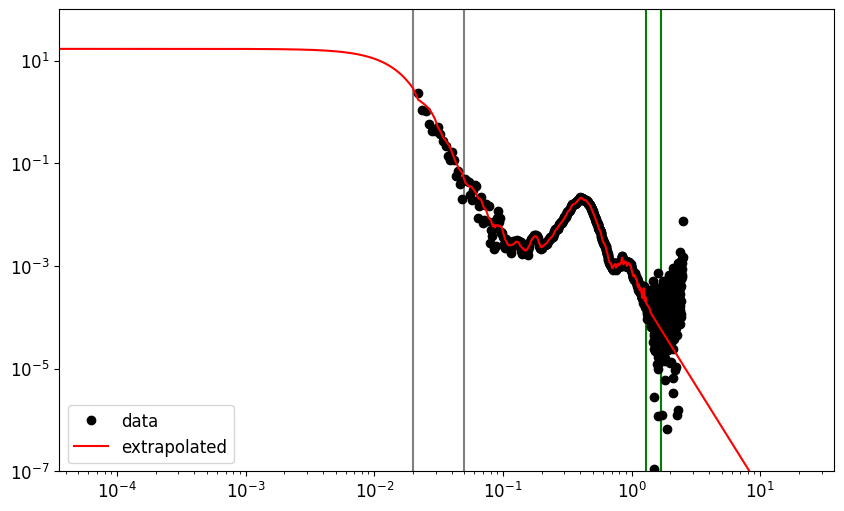

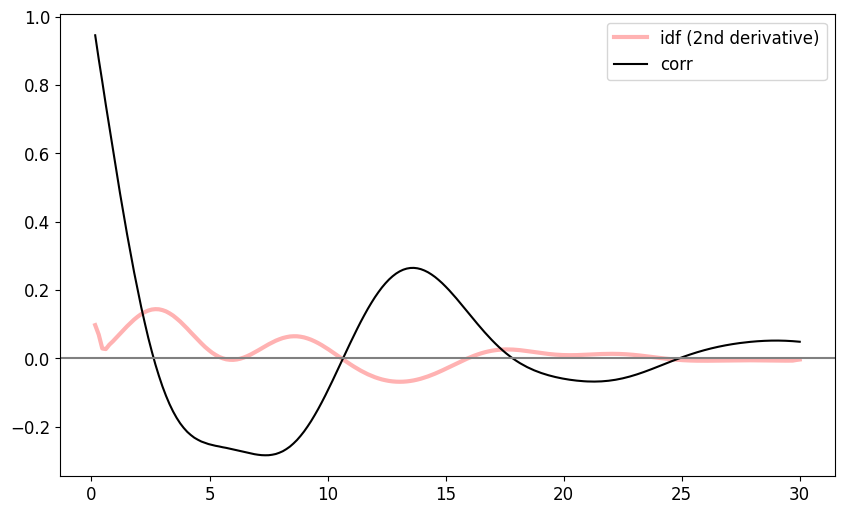

In [666]:
qmin = .03
i = 25
q, I = average(Exp_Heat, [i*2, i*2+1, i*2+2])
I = smooth_porod_region(q, I, (.1, 1.4), window=10)
I -= .9 * bkg
q = q[I>0]
I = I[I>0]

q_lim1, q_lim2 = .02, .05
q_lim3, q_lim4 = 1.3, 1.7


q_full, I_full, g, p = build_curve(
    q, I,
    guinier_range=(q_lim1, q_lim2),
    porod_range=(q_lim3, q_lim4),
    q_max=20,
    use_sigma=False,        # отключаем сигму
    K_factor=1.3,           # подкручиваем K на 20%
    smooth_width=0.        # ширина переходной зоны
)
I_full = smooth_porod_region(q_full, I_full, (.02, 20), window=10)

plt.axvline(x=q_lim1, color='grey')
plt.axvline(x=q_lim2, color='grey')
plt.axvline(x=q_lim3, color='g')
plt.axvline(x=q_lim4, color='g')

plt.plot(q, I, 'o', color='black', label='data')
plt.loglog(q_full, I_full, 'r', label='extrapolated')
# plt.loglog(q_full, I_full- .9 *p['bg'], '-', label='extrapolated (porod)')
plt.ylim(1e-7, 1e2)
plt.legend()
plt.show()

# Убедитесь что z и Gamma одной длины
N = 200
z, Gamma, _ = correlation(q_full, I_full, z_max=30, n_z=N)
z, IDF, _ = idf(q_full, I_full, z_max=30, n_z=N)

# Теперь обе функции с n_z=100
d2 = derivative2(z, Gamma)
plt.plot(z, d2, color='r', linewidth=3, alpha=.3, label='idf (2nd derivative)')
plt.plot(z, Gamma, color='black', label='corr')
# plt.plot(z[IDF<10], -IDF[IDF<10], color='b', label='idf Fourier')

plt.axhline(y=0, color='grey')
plt.legend()

In [667]:
idf_array.append(d2)
z_array.append(z)
i_array.append(i)

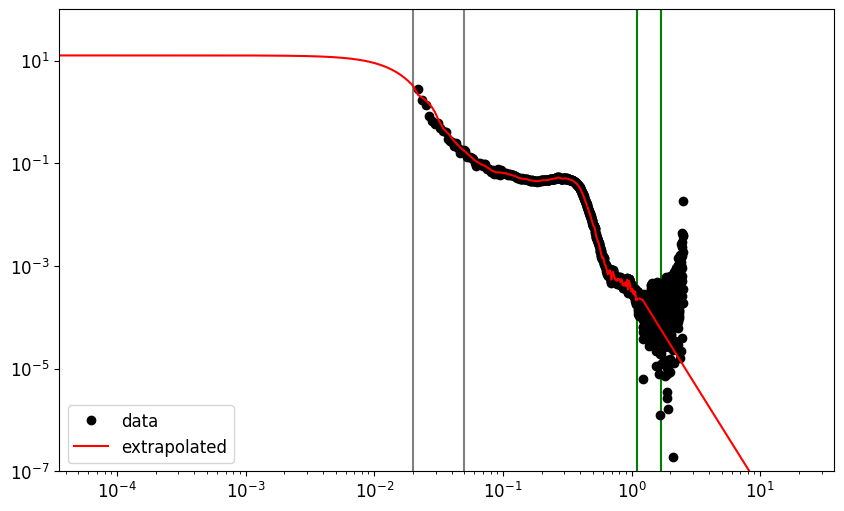

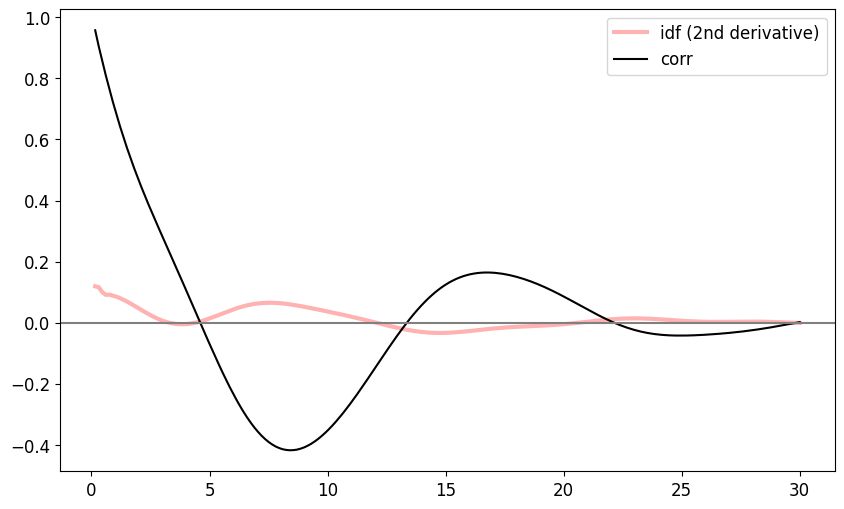

In [672]:
qmin = .03
i = 42
q, I = average(Exp_Heat, [i*2, i*2+1, i*2+2])
I = smooth_porod_region(q, I, (.1, 1.4), window=10)
I -= .9 * bkg
q = q[I>0]
I = I[I>0]

q_lim1, q_lim2 = .02, .05
q_lim3, q_lim4 = 1.1, 1.7


q_full, I_full, g, p = build_curve(
    q, I,
    guinier_range=(q_lim1, q_lim2),
    porod_range=(q_lim3, q_lim4),
    q_max=20,
    use_sigma=False,        # отключаем сигму
    K_factor=10,           # подкручиваем K на 20%
    smooth_width=0.        # ширина переходной зоны
)
I_full = smooth_porod_region(q_full, I_full, (.02, 20), window=10)

plt.axvline(x=q_lim1, color='grey')
plt.axvline(x=q_lim2, color='grey')
plt.axvline(x=q_lim3, color='g')
plt.axvline(x=q_lim4, color='g')

plt.plot(q, I, 'o', color='black', label='data')
plt.loglog(q_full, I_full, 'r', label='extrapolated')
# plt.loglog(q_full, I_full- .9 *p['bg'], '-', label='extrapolated (porod)')
plt.ylim(1e-7, 1e2)
plt.legend()
plt.show()

# Убедитесь что z и Gamma одной длины
N = 200
z, Gamma, _ = correlation(q_full, I_full, z_max=30, n_z=N)
z, IDF, _ = idf(q_full, I_full, z_max=30, n_z=N)

# Теперь обе функции с n_z=100
d2 = derivative2(z, Gamma)
plt.plot(z, d2, color='r', linewidth=3, alpha=.3, label='idf (2nd derivative)')
plt.plot(z, Gamma, color='black', label='corr')
# plt.plot(z[IDF<10], -IDF[IDF<10], color='b', label='idf Fourier')

plt.axhline(y=0, color='grey')
plt.legend()

In [570]:
idf_array.append(d2)
z_array.append(z)
i_array.append(i)

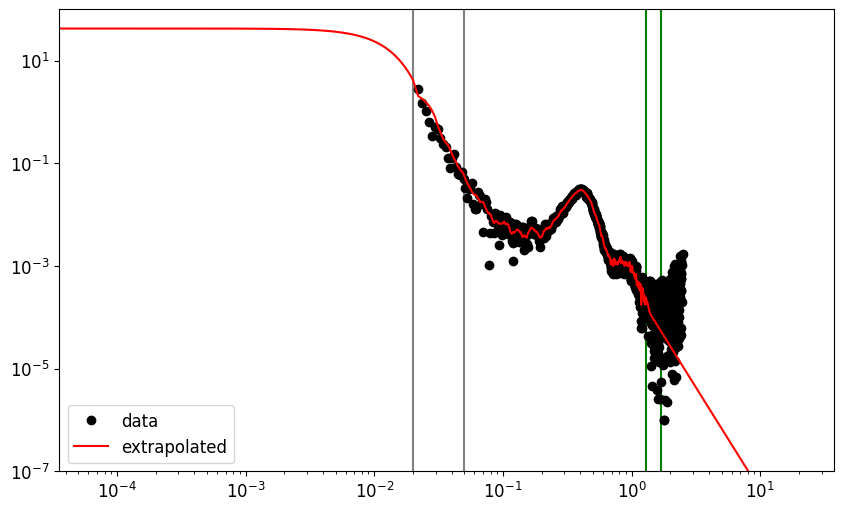

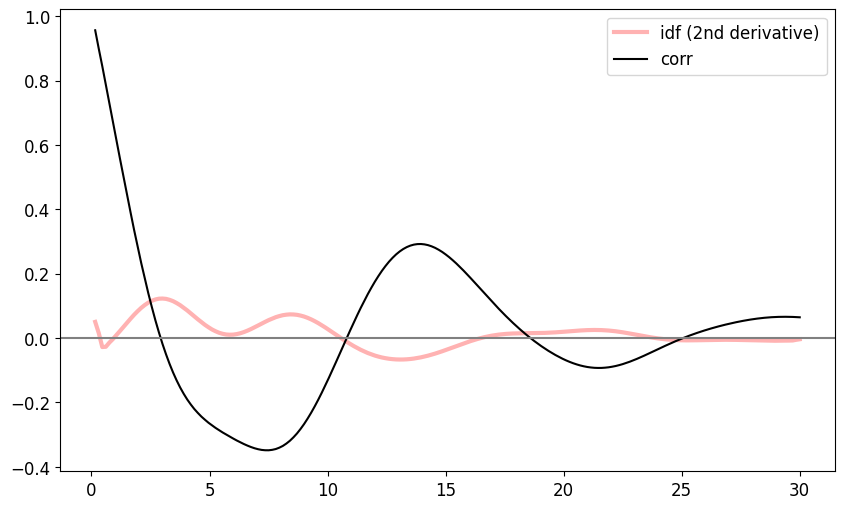

In [571]:
qmin = .03
i = 31
q, I = average(Exp_Heat, [i*2, i*2+1, i*2+2])
I -= .9 * bkg
q = q[I>0]
I = I[I>0]

q_lim1, q_lim2 = .02, .05
q_lim3, q_lim4 = 1.3, 1.7

I_smooth = smooth_porod_region(q, I, (.1, 1.4), window=2)


q_full, I_full, g, p = build_curve(
    q, I_smooth,
    guinier_range=(q_lim1, q_lim2),
    porod_range=(q_lim3, q_lim4),
    q_max=20,
    use_sigma=False,        # отключаем сигму
    K_factor=1.4,           # подкручиваем K на 20%
    smooth_width=0.        # ширина переходной зоны
)
I_full = smooth_porod_region(q_full, I_full, (.02, 20), window=10)

plt.axvline(x=q_lim1, color='grey')
plt.axvline(x=q_lim2, color='grey')
plt.axvline(x=q_lim3, color='g')
plt.axvline(x=q_lim4, color='g')

plt.plot(q, I_smooth, 'o', color='black', label='data')
plt.loglog(q_full, I_full, 'r', label='extrapolated')
# plt.loglog(q_full, I_full- .9 *p['bg'], '-', label='extrapolated (porod)')
plt.ylim(1e-7, 1e2)
plt.legend()
plt.show()

# Убедитесь что z и Gamma одной длины
N = 200
z, Gamma, _ = correlation(q_full, I_full, z_max=30, n_z=N)
z, IDF, _ = idf(q_full, I_full, z_max=30, n_z=N)

# Теперь обе функции с n_z=100
d2 = derivative2(z, Gamma)
plt.plot(z, d2, color='r', linewidth=3, alpha=.3, label='idf (2nd derivative)')
plt.plot(z, Gamma, color='black', label='corr')
# plt.plot(z[IDF<10], -IDF[IDF<10], color='b', label='idf Fourier')

plt.axhline(y=0, color='grey')
plt.legend()

In [572]:
idf_array.append(d2)
z_array.append(z)
i_array.append(i)

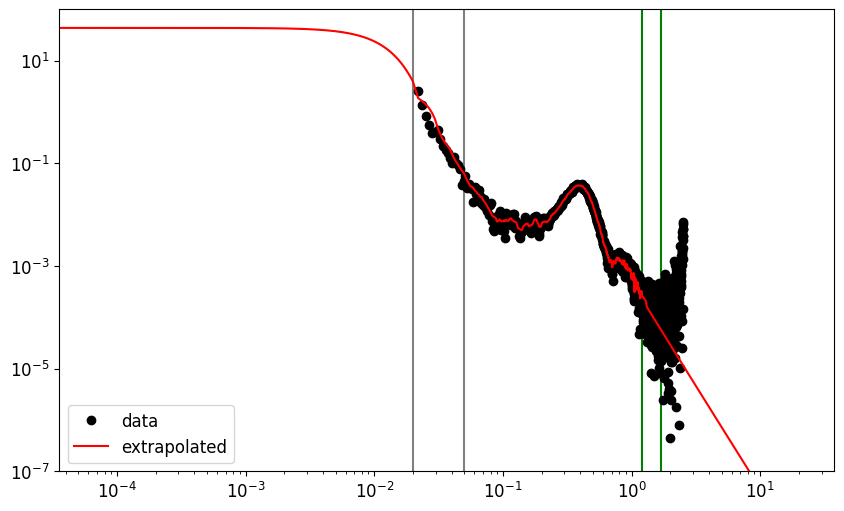

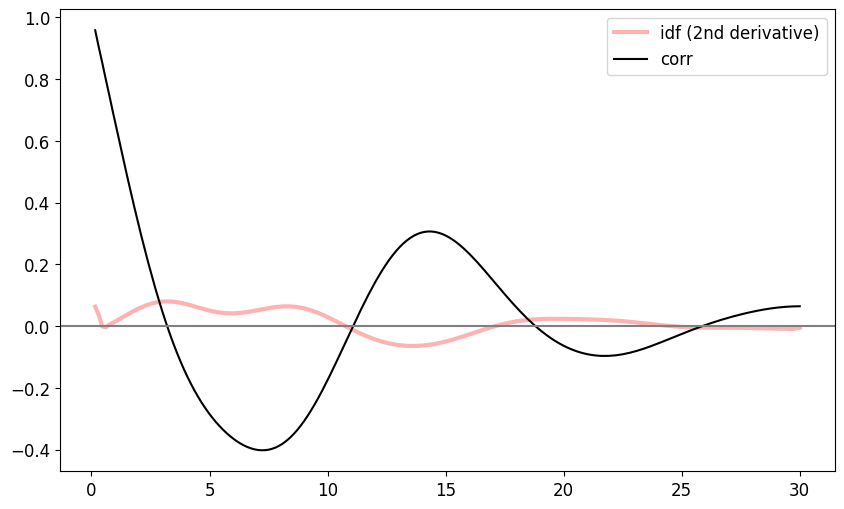

In [577]:
qmin = .03
i = 34
q, I = average(Exp_Heat, [i*2, i*2+1, i*2+2])
I -= .9 * bkg
q = q[I>0]
I = I[I>0]

q_lim1, q_lim2 = .02, .05
q_lim3, q_lim4 = 1.2, 1.7

I_smooth = smooth_porod_region(q, I, (.1, 1.4), window=2)


q_full, I_full, g, p = build_curve(
    q, I_smooth,
    guinier_range=(q_lim1, q_lim2),
    porod_range=(q_lim3, q_lim4),
    q_max=20,
    use_sigma=False,        # отключаем сигму
    K_factor=1.4,           # подкручиваем K на 20%
    smooth_width=0.        # ширина переходной зоны
)
I_full = smooth_porod_region(q_full, I_full, (.02, 20), window=10)

plt.axvline(x=q_lim1, color='grey')
plt.axvline(x=q_lim2, color='grey')
plt.axvline(x=q_lim3, color='g')
plt.axvline(x=q_lim4, color='g')

plt.plot(q, I_smooth, 'o', color='black', label='data')
plt.loglog(q_full, I_full, 'r', label='extrapolated')
# plt.loglog(q_full, I_full- .9 *p['bg'], '-', label='extrapolated (porod)')
plt.ylim(1e-7, 1e2)
plt.legend()
plt.show()

# Убедитесь что z и Gamma одной длины
N = 200
z, Gamma, _ = correlation(q_full, I_full, z_max=30, n_z=N)
z, IDF, _ = idf(q_full, I_full, z_max=30, n_z=N)

# Теперь обе функции с n_z=100
d2 = derivative2(z, Gamma)
plt.plot(z, d2, color='r', linewidth=3, alpha=.3, label='idf (2nd derivative)')
plt.plot(z, Gamma, color='black', label='corr')
# plt.plot(z[IDF<10], -IDF[IDF<10], color='b', label='idf Fourier')

plt.axhline(y=0, color='grey')
plt.legend()

In [578]:
idf_array.append(d2)
z_array.append(z)
i_array.append(i)

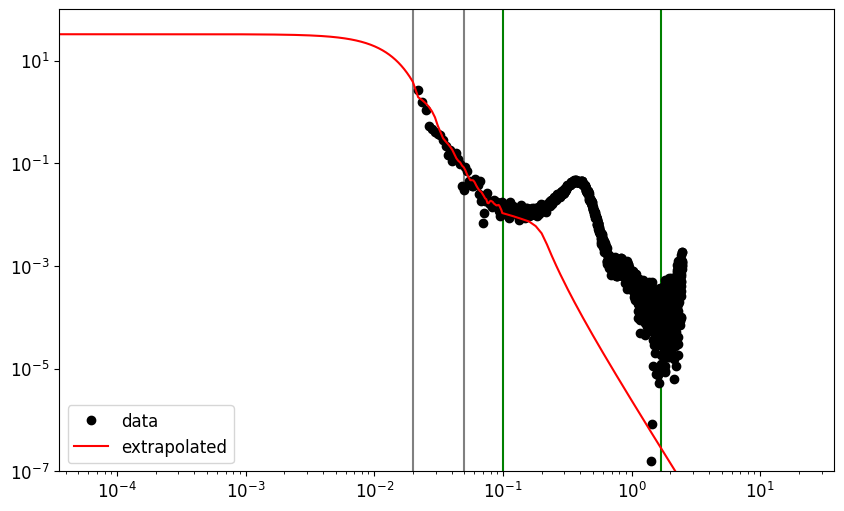

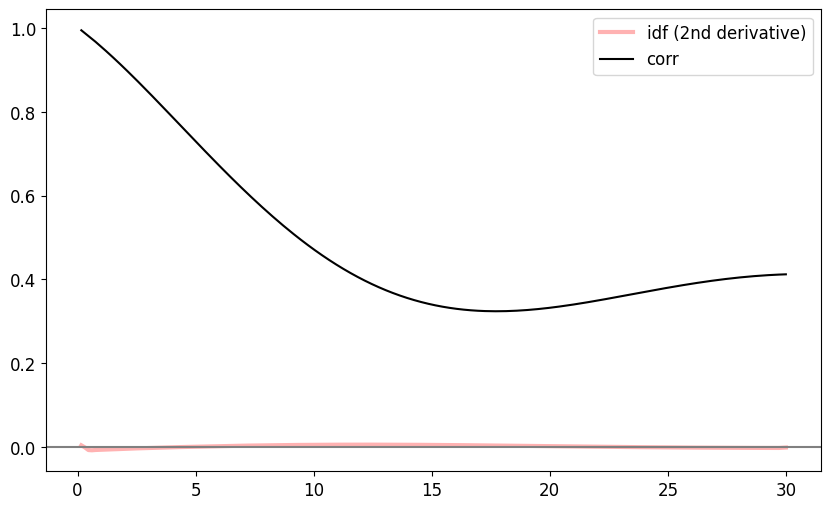

In [595]:
qmin = .03
i = 37
q, I = average(Exp_Heat, [i*2, i*2+1, i*2+2])
I -= .9 * bkg
q = q[I>0]
I = I[I>0]

q_lim1, q_lim2 = .02, .05
q_lim3, q_lim4 = .1, 1.7

I_smooth = smooth_porod_region(q, I, (.1, 1.4), window=2)


q_full, I_full, g, p = build_curve(
    q, I_smooth,
    guinier_range=(q_lim1, q_lim2),
    porod_range=(q_lim3, q_lim4),
    q_max=20,
    use_sigma=False,        # отключаем сигму
    K_factor=1.5,           # подкручиваем K на 20%
    smooth_width=0.        # ширина переходной зоны
)
I_full = smooth_porod_region(q_full, I_full, (.02, 20), window=10)

plt.axvline(x=q_lim1, color='grey')
plt.axvline(x=q_lim2, color='grey')
plt.axvline(x=q_lim3, color='g')
plt.axvline(x=q_lim4, color='g')

plt.plot(q, I_smooth, 'o', color='black', label='data')
plt.loglog(q_full, I_full, 'r', label='extrapolated')
# plt.loglog(q_full, I_full- .9 *p['bg'], '-', label='extrapolated (porod)')
plt.ylim(1e-7, 1e2)
plt.legend()
plt.show()

# Убедитесь что z и Gamma одной длины
N = 200
z, Gamma, _ = correlation(q_full, I_full, z_max=30, n_z=N)
z, IDF, _ = idf(q_full, I_full, z_max=30, n_z=N)

# Теперь обе функции с n_z=100
d2 = derivative2(z, Gamma)
plt.plot(z, d2, color='r', linewidth=3, alpha=.3, label='idf (2nd derivative)')
plt.plot(z, Gamma, color='black', label='corr')
# plt.plot(z[IDF<10], -IDF[IDF<10], color='b', label='idf Fourier')

plt.axhline(y=0, color='grey')
plt.legend()

In [585]:
idf_array.append(d2)
z_array.append(z)
i_array.append(i)

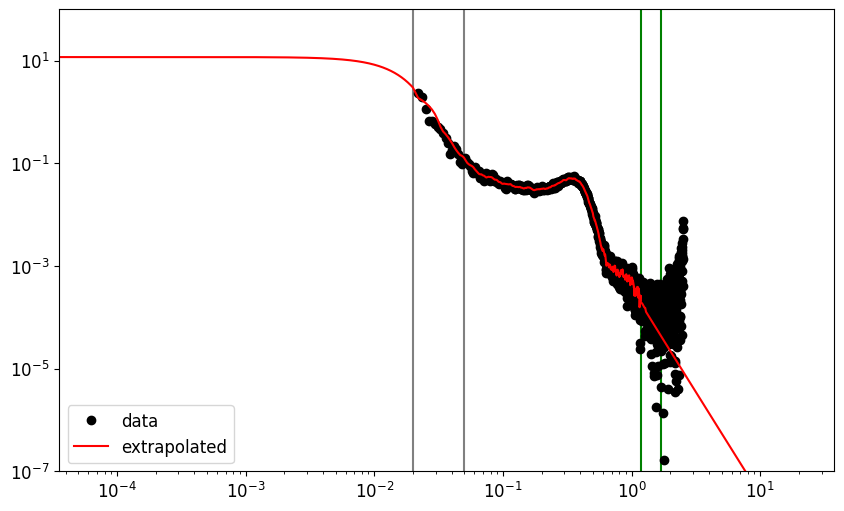

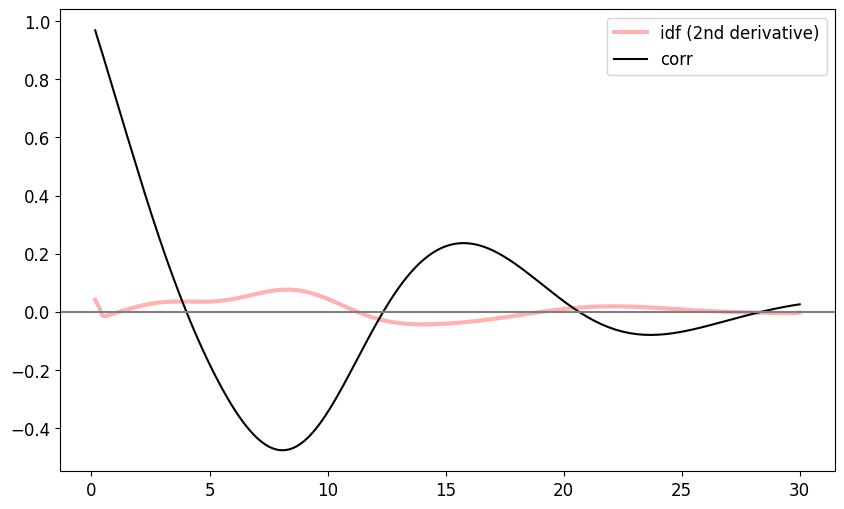

In [537]:
qmin = .03
i = 40
q, I = average(Exp_Heat, [i*2, i*2+1, i*2+2])
I -= .9 * bkg
q = q[I>0]
I = I[I>0]

q_lim1, q_lim2 = .02, .05
q_lim3, q_lim4 = 1.18, 1.7

I_smooth = smooth_porod_region(q, I, (.1, 1.4), window=2)


q_full, I_full, g, p = build_curve(
    q, I_smooth,
    guinier_range=(q_lim1, q_lim2),
    porod_range=(q_lim3, q_lim4),
    q_max=20,
    use_sigma=False,        # отключаем сигму
    K_factor=1.5,           # подкручиваем K на 20%
    smooth_width=0.        # ширина переходной зоны
)
I_full = smooth_porod_region(q_full, I_full, (.02, 20), window=10)

plt.axvline(x=q_lim1, color='grey')
plt.axvline(x=q_lim2, color='grey')
plt.axvline(x=q_lim3, color='g')
plt.axvline(x=q_lim4, color='g')

plt.plot(q, I_smooth, 'o', color='black', label='data')
plt.loglog(q_full, I_full, 'r', label='extrapolated')
# plt.loglog(q_full, I_full- .9 *p['bg'], '-', label='extrapolated (porod)')
plt.ylim(1e-7, 1e2)
plt.legend()
plt.show()

# Убедитесь что z и Gamma одной длины
N = 200
z, Gamma, _ = correlation(q_full, I_full, z_max=30, n_z=N)
z, IDF, _ = idf(q_full, I_full, z_max=30, n_z=N)

# Теперь обе функции с n_z=100
d2 = derivative2(z, Gamma)
plt.plot(z, d2, color='r', linewidth=3, alpha=.3, label='idf (2nd derivative)')
plt.plot(z, Gamma, color='black', label='corr')
# plt.plot(z[IDF<10], -IDF[IDF<10], color='b', label='idf Fourier')

plt.axhline(y=0, color='grey')
plt.legend()

In [538]:
idf_array.append(d2)
z_array.append(z)
i_array.append(i)

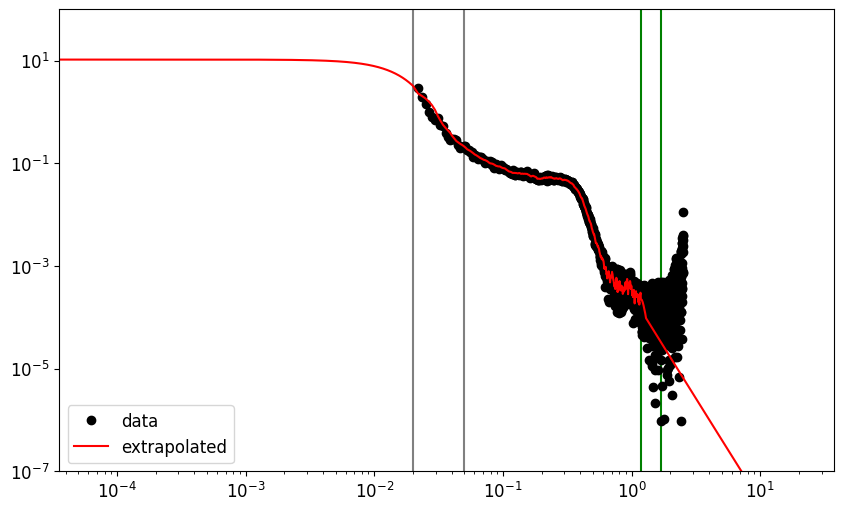

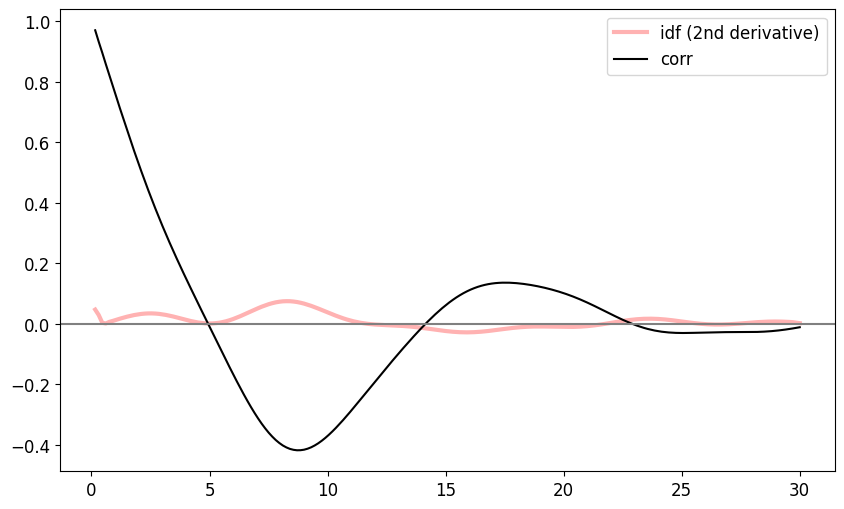

In [560]:
qmin = .03
i = 43
q, I = average(Exp_Heat, [i*2, i*2+1, i*2+2])
I -= .9 * bkg
q = q[I>0]
I = I[I>0]

q_lim1, q_lim2 = .02, .05
q_lim3, q_lim4 = 1.18, 1.7

I_smooth = smooth_porod_region(q, I, (.1, 1.4), window=2)


q_full, I_full, g, p = build_curve(
    q, I_smooth,
    guinier_range=(q_lim1, q_lim2),
    porod_range=(q_lim3, q_lim4),
    q_max=20,
    use_sigma=False,        # отключаем сигму
    K_factor=3.,           # подкручиваем K на 20%
    smooth_width=0.        # ширина переходной зоны
)
I_full = smooth_porod_region(q_full, I_full, (.02, 20), window=10)

plt.axvline(x=q_lim1, color='grey')
plt.axvline(x=q_lim2, color='grey')
plt.axvline(x=q_lim3, color='g')
plt.axvline(x=q_lim4, color='g')

plt.plot(q, I_smooth, 'o', color='black', label='data')
plt.loglog(q_full, I_full, 'r', label='extrapolated')
# plt.loglog(q_full, I_full- .9 *p['bg'], '-', label='extrapolated (porod)')
plt.ylim(1e-7, 1e2)
plt.legend()
plt.show()

# Убедитесь что z и Gamma одной длины
N = 200
z, Gamma, _ = correlation(q_full, I_full, z_max=30, n_z=N)
z, IDF, _ = idf(q_full, I_full, z_max=30, n_z=N)

# Теперь обе функции с n_z=100
d2 = derivative2(z, Gamma)
plt.plot(z, d2, color='r', linewidth=3, alpha=.3, label='idf (2nd derivative)')
plt.plot(z, Gamma, color='black', label='corr')
# plt.plot(z[IDF<10], -IDF[IDF<10], color='b', label='idf Fourier')

plt.axhline(y=0, color='grey')
plt.legend()

In [561]:
idf_array.append(d2)
z_array.append(z)
i_array.append(i)

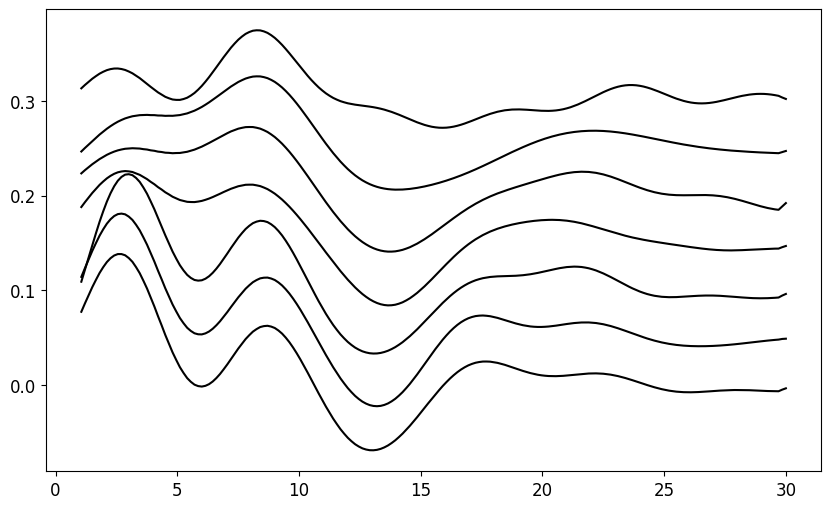

In [564]:
for i in range(len(i_array)):
    z_i = z_array[i]
    idf_i = idf_array[i]
    # plt.axhline(y =i * .05, color='grey' )
    plt.plot(z_i[z_i > 1], idf_i[z_i > 1] + i * .05, color='black')

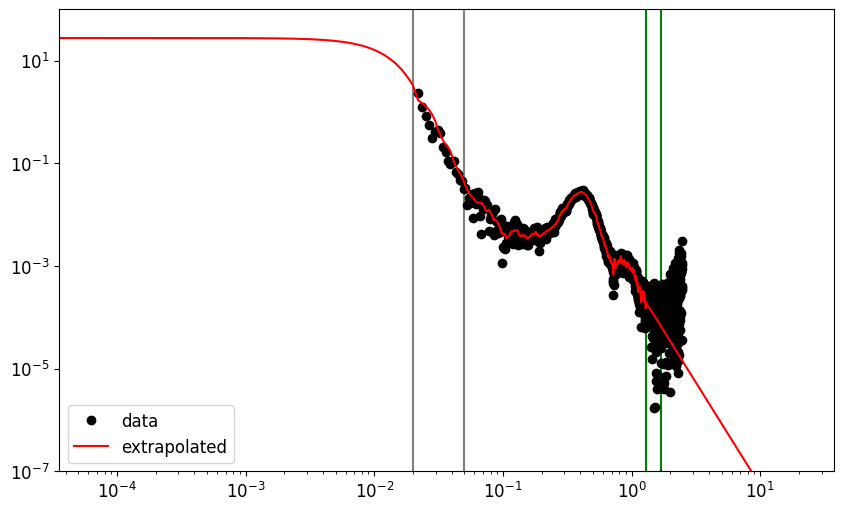

{'K': np.float64(0.0005210936485676623),
 'bg': np.float64(6.453707689060922e-05)}

In [405]:
qmin = .03
i = 30
q, I = average(Exp_Heat, [i*2, i*2+1, i*2+2])
I -= .9 * bkg
q = q[I>0]
I = I[I>0]

q_lim1, q_lim2 = .02, .05
q_lim3, q_lim4 = 1.3, 1.7

I_smooth = smooth_porod_region(q, I, (.1, 1.4), window=2)


q_full, I_full, g, p = build_curve(
    q, I_smooth,
    guinier_range=(q_lim1, q_lim2),
    porod_range=(q_lim3, q_lim4),
    q_max=20,
    use_sigma=False,        # отключаем сигму
    K_factor=1.,           # подкручиваем K на 20%
    smooth_width=0.        # ширина переходной зоны
)
I_full = smooth_porod_region(q_full, I_full, (.02, 20), window=10)

plt.axvline(x=q_lim1, color='grey')
plt.axvline(x=q_lim2, color='grey')
plt.axvline(x=q_lim3, color='g')
plt.axvline(x=q_lim4, color='g')

plt.plot(q, I_smooth, 'o', color='black', label='data')
plt.loglog(q_full, I_full, 'r', label='extrapolated')
# plt.loglog(q_full, I_full- .9 *p['bg'], '-', label='extrapolated (porod)')
plt.ylim(1e-7, 1e2)
plt.legend()
plt.show()

p

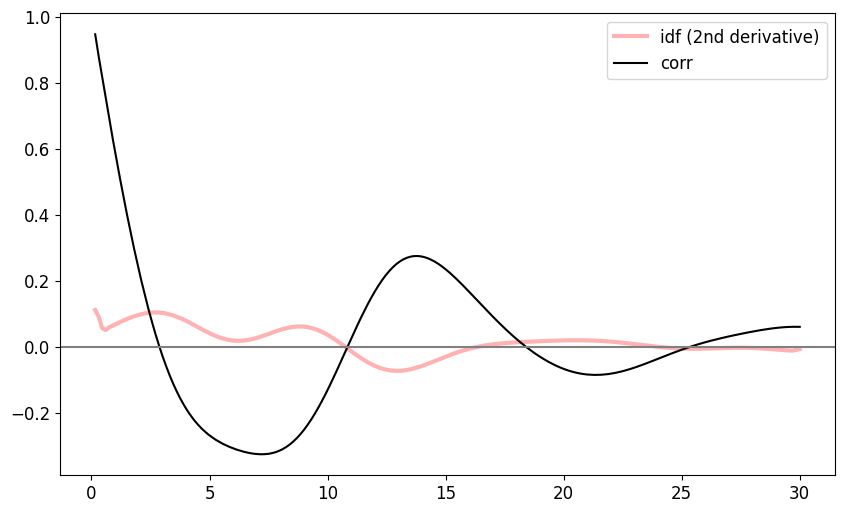

In [406]:
# Убедитесь что z и Gamma одной длины
N = 200
z, Gamma, _ = correlation(q_full, I_full, z_max=30, n_z=N)
z, IDF, _ = idf(q_full, I_full, z_max=30, n_z=N)

# Теперь обе функции с n_z=100
d2 = derivative2(z, Gamma)
plt.plot(z, d2, color='r', linewidth=3, alpha=.3, label='idf (2nd derivative)')
plt.plot(z, Gamma, color='black', label='corr')
# plt.plot(z[IDF<10], -IDF[IDF<10], color='b', label='idf Fourier')

plt.axhline(y=0, color='grey')
plt.legend()

In [407]:
z1,gamma1,idf1 = z,Gamma,d2

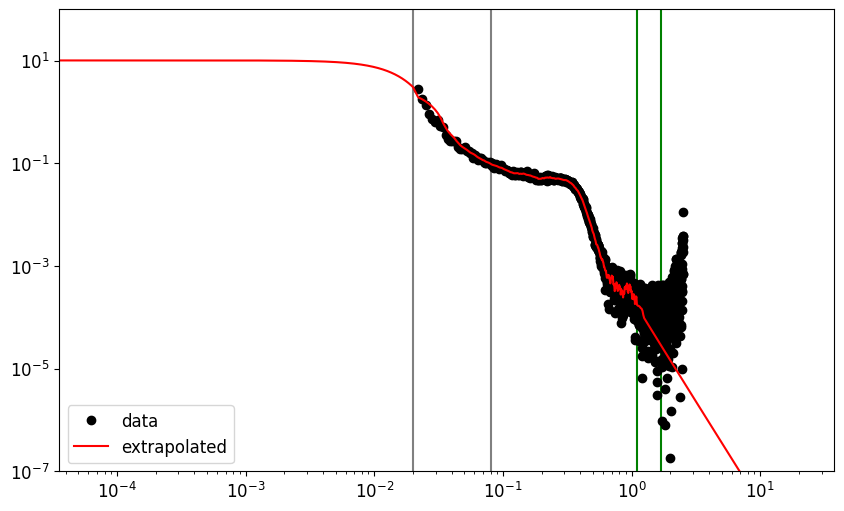

{'K': np.float64(0.00022495216004324019),
 'bg': np.float64(0.00010250190302652945)}

In [422]:
qmin = .03
i = 43
q, I = average(Exp_Heat, [i*2, i*2+1, i*2+2])
I -= .99 * bkg
q = q[I>0]
I = I[I>0]

q_lim1, q_lim2 = .02, .08
q_lim3, q_lim4 = 1.1, 1.7

I_smooth = smooth_porod_region(q, I, (.1, 1.4), window=2)


q_full, I_full, g, p = build_curve(
    q, I_smooth,
    guinier_range=(q_lim1, q_lim2),
    porod_range=(q_lim3, q_lim4),
    q_max=20,
    use_sigma=False,        # отключаем сигму
    K_factor=1.6,           # подкручиваем K на 20%
    smooth_width=0.        # ширина переходной зоны
)
I_full = smooth_porod_region(q_full, I_full, (.02, 20), window=15)

plt.axvline(x=q_lim1, color='grey')
plt.axvline(x=q_lim2, color='grey')
plt.axvline(x=q_lim3, color='g')
plt.axvline(x=q_lim4, color='g')

plt.plot(q, I_smooth, 'o', color='black', label='data')
plt.loglog(q_full, I_full, 'r', label='extrapolated')
# plt.loglog(q_full, I_full- .9 *p['bg'], '-', label='extrapolated (porod)')
plt.ylim(1e-7, 1e2)
plt.legend()
plt.show()

p

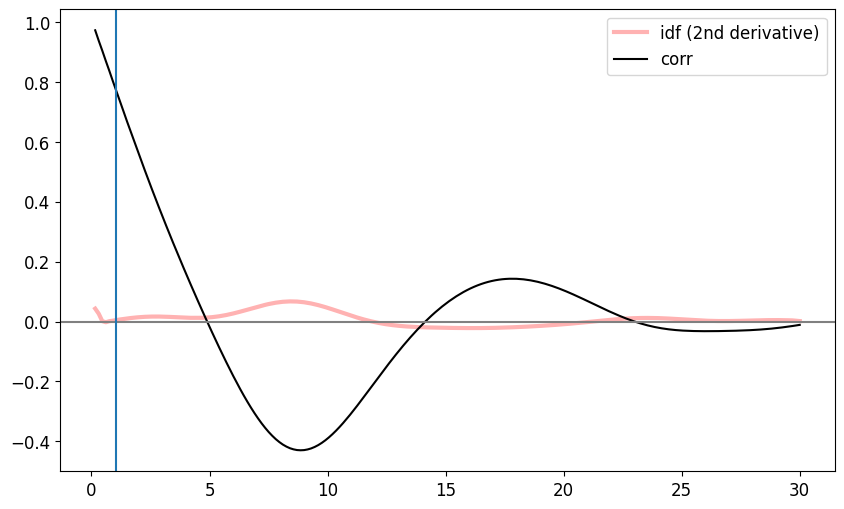

In [423]:
# Убедитесь что z и Gamma одной длины
N = 200
z, Gamma, _ = correlation(q_full, I_full, z_max=30, n_z=N)
z, IDF, _ = idf(q_full, I_full, z_max=30, n_z=N)

# Теперь обе функции с n_z=100
d2 = derivative2(z, Gamma)
plt.plot(z, d2, color='r', linewidth=3, alpha=.3, label='idf (2nd derivative)')
plt.plot(z, Gamma, color='black', label='corr')
# plt.plot(z[IDF<10], -IDF[IDF<10], color='b', label='idf Fourier')

plt.axhline(y=0, color='grey')
plt.legend()
plt.axvline(x=1.57/1.5)

In [424]:
z2,gamma2,idf2 = z,Gamma,d2

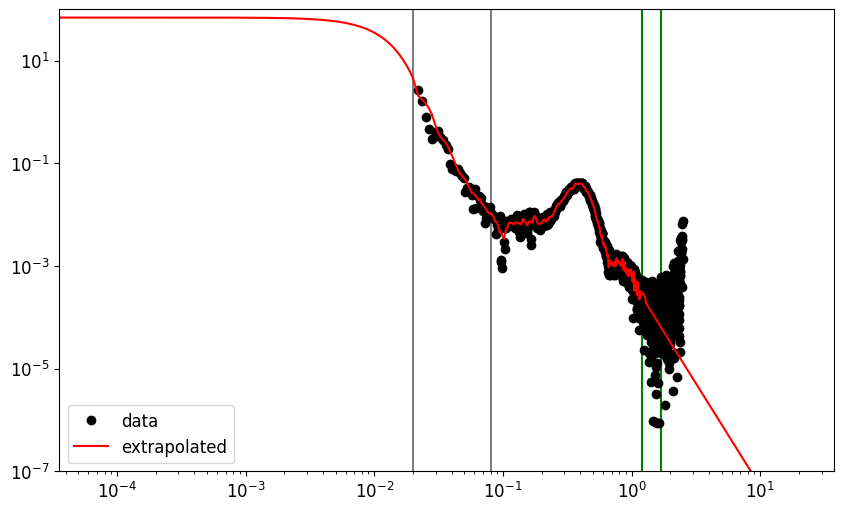

{'K': np.float64(0.0005019707298722648),
 'bg': np.float64(8.990655097404848e-05)}

In [501]:
qmin = .03
i = 35
q, I = average(Exp_Heat, [i*2, i*2+1])
I -= .99 * bkg
q = q[I>0]
I = I[I>0]

q_lim1, q_lim2 = .02, .08
q_lim3, q_lim4 = 1.2, 1.7

I_smooth = smooth_porod_region(q, I, (.1, 1.4), window=2)


q_full, I_full, g, p = build_curve(
    q, I_smooth,
    guinier_range=(q_lim1, q_lim2),
    porod_range=(q_lim3, q_lim4),
    q_max=20,
    use_sigma=False,        # отключаем сигму
    K_factor=1.4,           # подкручиваем K на 20%
    smooth_width=0.        # ширина переходной зоны
)
I_full = smooth_porod_region(q_full, I_full, (.02, 20), window=8)

plt.axvline(x=q_lim1, color='grey')
plt.axvline(x=q_lim2, color='grey')
plt.axvline(x=q_lim3, color='g')
plt.axvline(x=q_lim4, color='g')

plt.plot(q, I_smooth, 'o', color='black', label='data')
plt.loglog(q_full, I_full, 'r', label='extrapolated')
# plt.loglog(q_full, I_full- .9 *p['bg'], '-', label='extrapolated (porod)')
plt.ylim(1e-7, 1e2)
plt.legend()
plt.show()

p

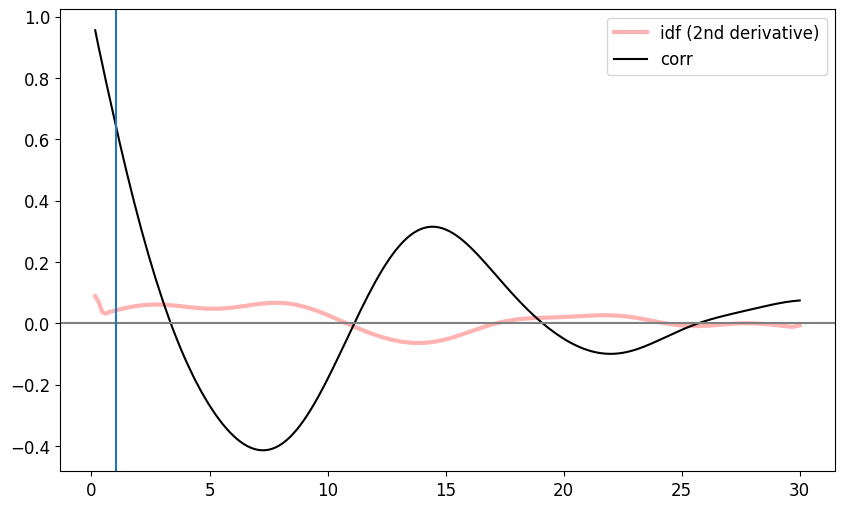

In [502]:
# Убедитесь что z и Gamma одной длины
N = 200
z, Gamma, _ = correlation(q_full, I_full, z_max=30, n_z=N)
z, IDF, _ = idf(q_full, I_full, z_max=30, n_z=N)

# Теперь обе функции с n_z=100
d2 = derivative2(z, Gamma)
plt.plot(z, d2, color='r', linewidth=3, alpha=.3, label='idf (2nd derivative)')
plt.plot(z, Gamma, color='black', label='corr')
# plt.plot(z[IDF<10], -IDF[IDF<10], color='b', label='idf Fourier')

plt.axhline(y=0, color='grey')
plt.legend()
plt.axvline(x=1.57/1.5)

In [503]:
z3,gamma3,idf3 = z,Gamma,d2

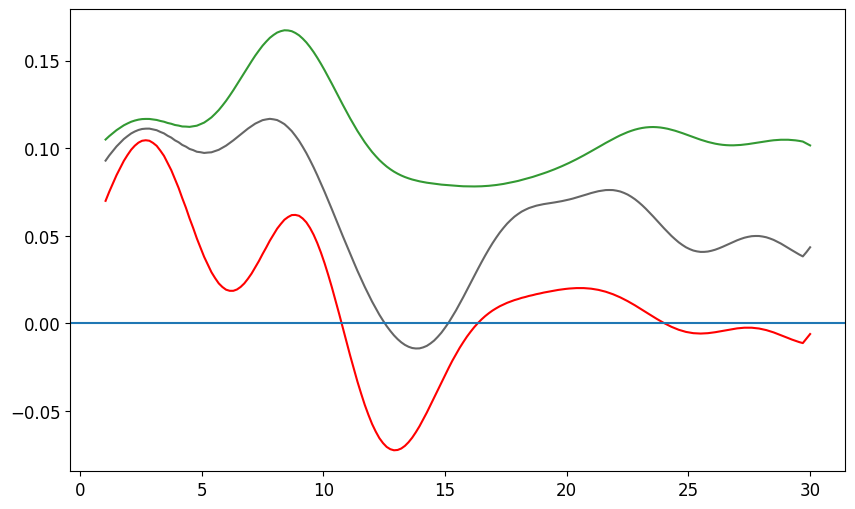

In [506]:
plt.plot(z1[z1>1], idf1[z1>1], color='r', alpha=1)
plt.plot(z2[z2>1], idf2[z2>1] + .1, color='g', alpha=.8)
plt.plot(z3[z3>1], idf3[z3>1] + .05, color='black', alpha=.6)
plt.axhline(y=0)